## Imports & Loads

In [1]:
CANVAS_SIZE = (440, 440)

In [2]:
from PIL import Image, ImageOps
def resize_image(image: Image):
    if len(image.getbands()) == 1:
        PADDING_COLOR = 0  # Single integer for grayscale/depth maps
    else:
        PADDING_COLOR = (0, 0, 0)  # Tuple for RGB images
    return ImageOps.pad(image, CANVAS_SIZE, color=PADDING_COLOR)

In [3]:
from transformers import pipeline
import os
import matplotlib.pyplot as plt

c:\Users\Simon\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
depth_estimator = pipeline(
    "depth-estimation",
    model="Intel/dpt-hybrid-midas",
    api_key=os.environ["HF_TOKEN"]
)

Loading weights: 100%|██████████| 414/414 [00:00<00:00, 15876.18it/s]


In [5]:
from ultralytics import YOLO
model = YOLO("stroke_generation/yolo11x-seg.pt")

## Image Pre-loading

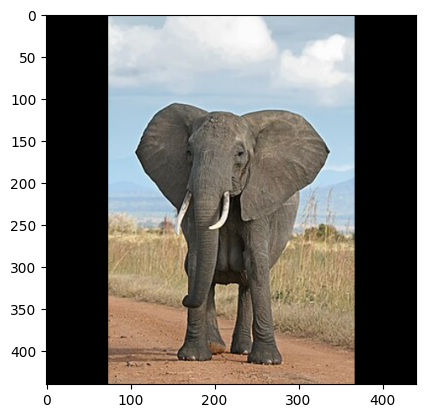

In [6]:
import numpy as np
from PIL import Image, ImageOps
from skimage.segmentation import slic

# 1. Load your PIL image
pil_original_image = Image.open("C:/Users/Simon/Documents/projecten/paint-bot/images/elephant.jpg")

# 2. Resize to 440x440 (stretches to fit exactly, no whitespace padding)
pil_resized_image = resize_image(pil_original_image)

# 3. Convert the resized PIL image to a NumPy array
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

plt.imshow(np_resized_image)
plt.show()

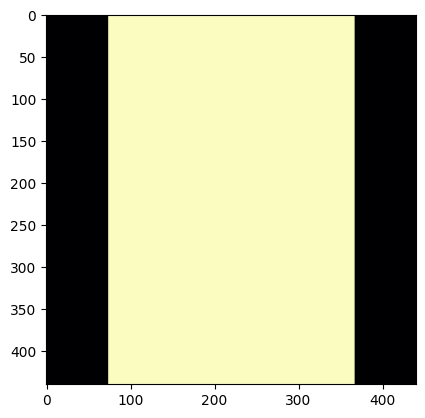

In [7]:
# 3. Create a "dummy" pure white image of the exact same original size
# This represents our "real pixels" mask BEFORE padding
mask_canvas = Image.new("L", pil_original_image.size, color=255)

# 4. Apply the exact same padding transformation to the mask canvas
# ImageOps.pad will scale and pad this mask identically to the elephant image
padded_mask = ImageOps.pad(mask_canvas, CANVAS_SIZE, color=0)

# 5. Convert mask to a 1 and 0 NumPy array
# Wherever the padded_mask is 255 (white), it's a real pixel (1). Otherwise, it's 0.
padding_mask = (np.array(padded_mask) == 255).astype(np.uint8)
plt.imshow(padding_mask, cmap='magma')
plt.show()

## Depth map

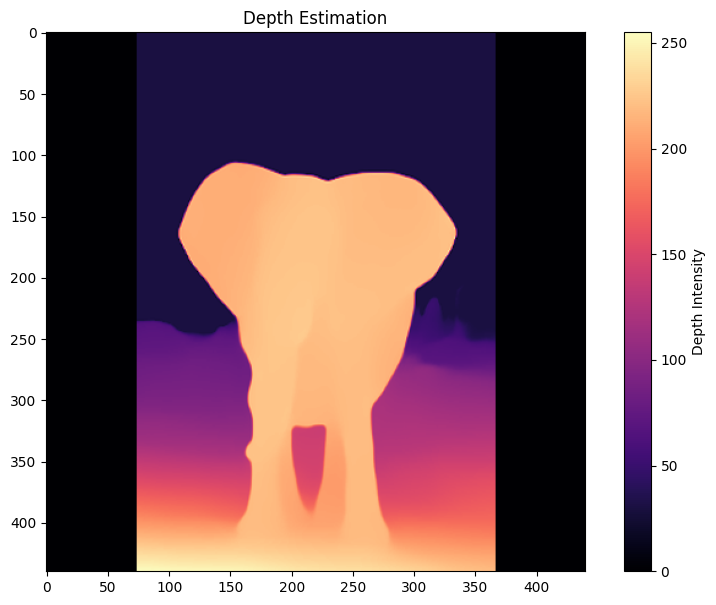

In [22]:
# Pass the original PIL image to the depth estimator
depth_prediction = depth_estimator(pil_original_image)

# Extract the depth map as a numpy array
depth_map_pil = depth_prediction["depth"]
resized_depth_map = np.array(resize_image ( depth_map_pil) )

fig, ax1 = plt.subplots(1, 1, figsize=(10, 7)) # Adjusted 20x7 to 10x7 so a single plot isn't stretched too wide
ax1.set_title("Depth Estimation")
im = ax1.imshow(resized_depth_map, cmap="magma")
fig.colorbar(im, ax=ax1, label="Depth Intensity")
plt.show()

## Segmentation

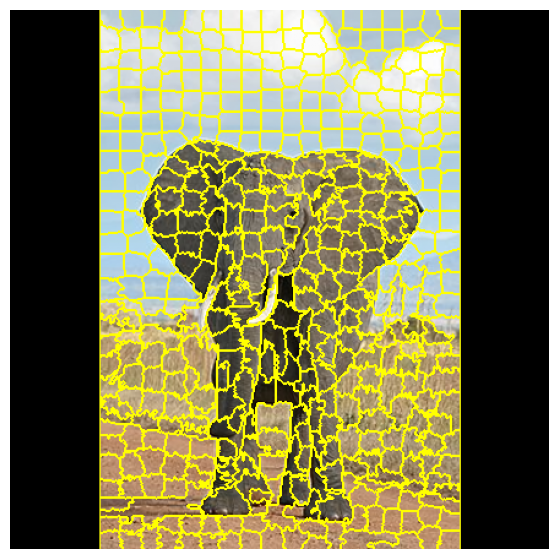

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from skimage.segmentation import mark_boundaries
from PIL import Image

# 1. Run SLIC on the original image as you did
# 1. Run SLIC on the original image as you did
segments = slic(
    np_original_image,
    n_segments=500,
    compactness=10
)

# 2. Cast to int32 so PIL can handle it, then resize using Nearest Neighbor
segments_int32 = segments.astype(np.int32) # <--- Added this line
segments_pil = Image.fromarray(segments_int32)

resized_segments_pil = ImageOps.pad(
    segments_pil, 
    CANVAS_SIZE, 
    method=Image.Resampling.NEAREST, 
    color=0
)
resized_segments = np.array(resized_segments_pil)


# 3. Calculate centroids on the NEW resized segments
for label in np.unique(resized_segments):
    # Mask out the background padding (label 0 might contain padding now)
    if label == 0: 
        continue
    centroid = center_of_mass(resized_segments == label)

# 4. Plot using the ALREADY resized/padded elephant image from your previous step
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(mark_boundaries(np_resized_image, resized_segments)) # 'image' is your 440x440 padded np array
# ax.setTitle("1. Resized SLIC Superpixel Segments", fontsize=14, fontweight='bold')
ax.axis("off")
plt.show()

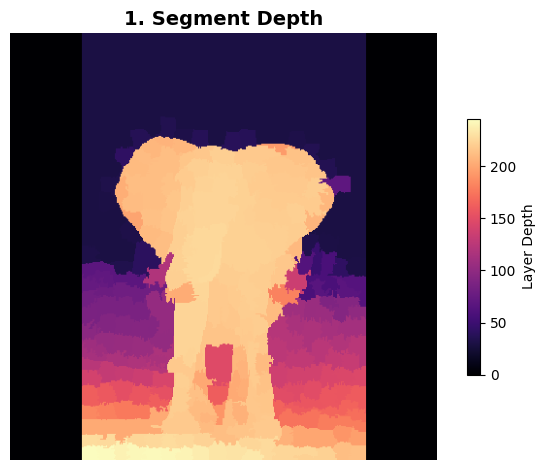

In [26]:
binned_depth_visualization = np.zeros_like(resized_segments, dtype=np.float32)

segment_labels = np.unique(segments)
segment_depths = []

for label in segment_labels:
    mask = (resized_segments == label)

    mean_depth = resized_depth_map[mask].mean()
    
    # Fill the entire segment region with its average depth value
    binned_depth_visualization[mask] = mean_depth

    segment_depths.append((label, mean_depth))

segment_depths.sort(key=lambda x: x[1], reverse=False) # sort segments

fig, ax = plt.subplots(1, 1)

im2 = ax.imshow(binned_depth_visualization, cmap="magma")
ax.set_title("1. Segment Depth", fontsize=14, fontweight='bold')
ax.axis("off")
fig.colorbar(im2, ax=ax, shrink=0.6, label="Layer Depth")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
import cv2  # Used strictly for footprint tracking on the internal mask
from datatypes import StrokePath, StrokeSequence

def generate_strokes_for_layer(stroke_sequence, segments, label, image, grad, coverage_mask,
                               max_stroke_list_length=60, min_stroke_length_pixels=10, error_threshold=50, target_coverage=0.90, brush_size = None,
                               max_attempts=100, min_coverage_score=.15
    ):
    """
    Generates curved robot toolpaths, dynamically seeding multiple strokes within 
    each superpixel until the specified target coverage percentage is met.
    """

    H, W, _ = image.shape

    gy, gx = grad
    sp_mask = (segments == label)
    total_sp_pixels = np.sum(sp_mask)
    
    if total_sp_pixels < 5:
        raise RuntimeError("Superpixel too small.")
        
    # Local coverage loop for this specific superpixel
    attempts = 0
    niceness = 0
    while attempts < max_attempts:
        niceness = min(1, attempts / (max_attempts)) # 0 -> 1

        # Calculate what % of this superpixel is currently covered
        covered_sp_pixels = np.sum(coverage_mask & sp_mask)
        current_coverage = covered_sp_pixels / total_sp_pixels
        
        # Stop spawning new strokes in this patch if we reached our target fill rate
        if current_coverage >= target_coverage:
            # print("coverage reached.")
            return # OK
            
        # Find all pixels in the superpixel that are still bare/unpainted
        unpainted_indices = np.argwhere(sp_mask & ~coverage_mask)
        if len(unpainted_indices) == 0:
            # print("All painted.")
            return
            
        # For the first attempt, use the true center. For subsequent passes, 
        # pick the middle of the remaining unpainted clusters.
        if attempts == 0:
            cy, cx = np.mean(np.argwhere(sp_mask), axis=0)
        else:
            cy, cx = unpainted_indices[len(unpainted_indices) // 2]
            
        start_x_idx = int(np.clip(cx, 0, W - 1))
        start_y_idx = int(np.clip(cy, 0, H - 1))
        
        stroke_color = image[start_y_idx, start_x_idx]
        path = [(start_x_idx, start_y_idx)]
        
        curr_x, curr_y = float(start_x_idx), float(start_y_idx)
        last_dx, last_dy = 0.0, 0.0
        
        # Trace the curved line
        for _ in range(max_stroke_list_length):
            map_y, map_x = int(np.clip(curr_y, 0, H - 1)), int(np.clip(curr_x, 0, W - 1))
            
            gx_val = gx[map_y, map_x]
            gy_val = gy[map_y, map_x]
            
            dx, dy = -gy_val, gx_val
            mag = np.sqrt(dx**2 + dy**2)
            
            if mag == 0:
                if last_dx == 0 and last_dy == 0: 
                    break
                dx, dy = last_dx, last_dy
            else:
                dx, dy = dx / mag, dy / mag
                
            if len(path) > 1 and (dx * last_dx + dy * last_dy) < 0:
                dx, dy = -dx, -dy
                
            step_size = 3.0
            next_x = curr_x + dx * step_size
            next_y = curr_y + dy * step_size
            
            next_x_idx = int(np.clip(next_x, 0, W - 1))
            next_y_idx = int(np.clip(next_y, 0, H - 1))
            
            if next_x_idx == map_x and next_y_idx == map_y:
                break
                
            # Color threshold boundary limit check
            color_diff = np.linalg.norm(image[next_y_idx, next_x_idx] - stroke_color)
            error_factor = (1+1.2*niceness)
            if color_diff > error_threshold*error_factor:
                break
                
            path.append((next_x_idx, next_y_idx))
            curr_x, curr_y = next_x, next_y
            last_dx, last_dy = dx, dy

        path_np = np.array(path)

        # Calculate the differences between consecutive points
        # dx = x[1] - x[0], dy = y[1] - y[0]
        distances = np.diff(path_np, axis=0)

        # Calculate Euclidean distance for each segment: sqrt(dx^2 + dy^2)
        segment_lengths = np.sqrt(np.sum(distances**2, axis=1))

        # Sum them up to get the total stroke length
        stroke_length_pixels = np.sum(segment_lengths)
        
        length_factor = max(.1, 1 - 2*niceness)
        if stroke_length_pixels >= min_stroke_length_pixels * length_factor:
            # Convert path to an array structure cv2.polylines expects
            pts = np.array(path, dtype=np.int32).reshape((-1, 1, 2))
            
            # Draw the footprint of this stroke onto our layer mask tracker
            stroke_buffer = np.zeros((H, W), dtype=np.uint8)
            cv2.polylines(stroke_buffer, [pts], isClosed=False, color=255, thickness=brush_size)

            # Create a boolean mask for the current stroke
            current_stroke_mask = (stroke_buffer > 0)

            # 1. Over-painted area: Pixels in the current stroke that were ALREADY covered
            over_painted_mask = current_stroke_mask & coverage_mask
            over_painted_area = np.sum(over_painted_mask)

            # 2. Newly painted area: Pixels in the current stroke that were NOT previously covered
            newly_painted_mask = current_stroke_mask & ~coverage_mask
            newly_painted_area = np.sum(newly_painted_mask)

            # Give a score to this new stroke
            if (newly_painted_area + over_painted_area) == 0:
                coverage_mask[start_y_idx, start_x_idx] = True
                attempts += 1
                continue
            
            coverage_score = newly_painted_area / (newly_painted_area + over_painted_area)
            if coverage_score <= min_coverage_score:
                coverage_mask[start_y_idx, start_x_idx] = True
                attempts += 1
                continue
            
            # Absorb this footprint into our main coverage layer mask
            coverage_mask = coverage_mask | current_stroke_mask
            
            # Append the validated stroke to the sequence
            processed_color = stroke_color.tolist() if isinstance(stroke_color, np.ndarray) else stroke_color
            processed_color = tuple(int(c) for c in processed_color)
            
            stroke_sequence.strokes.append(StrokePath(
                color=processed_color,
                path=path,
                brushWidth=brush_size,
            ))
        else:
            # If the stroke was rejected for being too short, we mark the initial seed point 
            # as 'painted' in our tracking array anyway.
            coverage_mask[start_y_idx, start_x_idx] = True
            attempts += 1
            continue

In [ ]:
# 1. Smooth the image to get a reliable, non-noisy gradient field
if np_resized_image.ndim == 3:
    gray = 0.299 * np_resized_image[:,:,0] + 0.587 * np_resized_image[:,:,1] + 0.114 * np_resized_image[:,:,2]
else:
    gray = np_resized_image.copy()

W, H, _ = np_resized_image.shape

gray_smoothed = gaussian_filter(gray, sigma=1.5)
gy, gx = np.gradient(gray_smoothed)

100%|██████████| 406/406 [00:43<00:00,  9.37it/s]


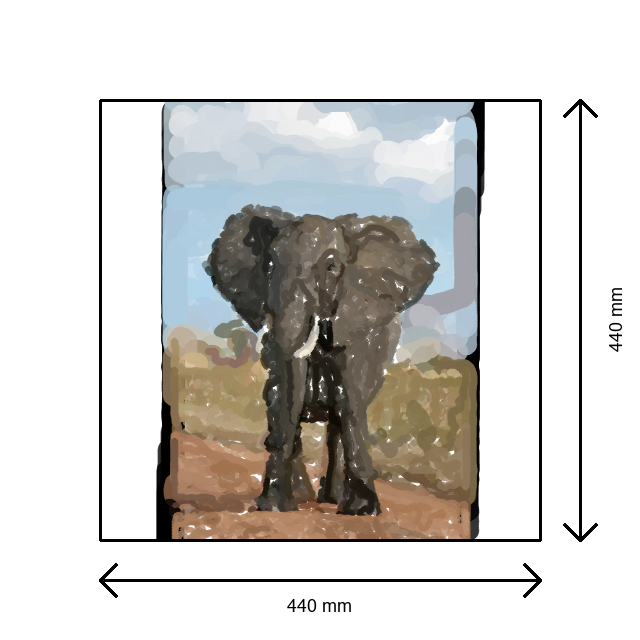

In [ ]:
from visualisation import visualize_stroke_sequence
from datatypes import StrokeSequence
from tqdm import tqdm # progress bar
import numpy as np


H, W, _ = np_resized_image.shape

stroke_sequence = StrokeSequence(image_size=(W, H))
coverage_mask = np.zeros((H, W), dtype=bool)

layer_settings = {
    0: {
        "brush_size": 10*2,
        "min_stroke_length_pixels": 120,
        "error_threshold": 150
    },
    80: {
        "brush_size": 3*2,
        "min_stroke_length_pixels": 30,
        "error_threshold": 100
    },
    200: {
        "brush_size": 2*2,
        "min_stroke_length_pixels": 20,
        "error_threshold": 90,
        "target_coverage": 0.95,
        "max_attempts": 200,
        "min_coverage_score": .10
    },
}

# Sort the depth thresholds ascendingly to easily find the correct bracket
sorted_thresholds = sorted(layer_settings.keys())

# Loop through the targeted depth layer bins (Back-to-Front ordering)
for label, mean_depth in tqdm(segment_depths):
    
    # Find the applicable setting bracket based on mean_depth
    applicable_threshold = 0
    for threshold in sorted_thresholds:
        if mean_depth >= threshold:
            applicable_threshold = threshold
        else:
            break # Since it's sorted, we can stop checking higher thresholds
            
    # Extract the base configurations dictionary
    settings = layer_settings[applicable_threshold]

    # Call the updated stroke generator function using dictionary unpacking (**)
    generate_strokes_for_layer(
        grad=(gy, gx),
        stroke_sequence=stroke_sequence, 
        segments=segments, 
        label=label, 
        image=np_resized_image, 
        coverage_mask=coverage_mask,
        # max_stroke_length=settings.get("max_stroke_length", 60), # Map if needed
        **settings # Unpacks brush_size, min_stroke_length_pixels, error_threshold dynamically
    )
    
visualize_stroke_sequence(stroke_sequence)

In [ ]:
from visualisation import animate_stroke_sequence

animate_stroke_sequence(stroke_sequence)

Start video rendering...


 78%|███████▊  | 1744/2235 [00:21<00:05, 82.68it/s]


KeyboardInterrupt: 

In [ ]:
stroke_sequence.save_to_json("data/my_stroke_sequence.json")